In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [17]:
runs = pd.read_csv("../debug/runs.csv")

In [18]:
labels = ["after", "before", "includes", "is_included", "simultaneous", "vague"]
models = labels[:-1]
modes = ["without", "only"]
seeds = [0, 1, 2]

In [19]:
# leave out

leave_out = pd.DataFrame({"class": labels})

avg_f1 = []
for model in models:
    for label in labels:
        scores = []
        for seed in seeds:
            row = runs.loc[runs["Name"] == f"without_{model}_seed_{seed}"]
            score = row[f"test_f1_{label} F1"].values[0]
            scores.append(score)
        avg_f1.append(sum(scores) / len(scores))
    leave_out[f"without_{model}"] = avg_f1
    avg_f1 = []

In [20]:
# only one

only_one = pd.DataFrame({"class": labels})

avg_f1 = []
for model in models:
    for label in labels:
        scores = []
        for seed in seeds:
            row = runs.loc[runs["Name"] == f"only_{model}_seed_{seed}"]
            score = row[f"test_f1_{label} F1"].values[0]
            scores.append(score)
        avg_f1.append(sum(scores) / len(scores))
    only_one[f"only_{model}"] = avg_f1
    avg_f1 = []

In [26]:
all_constraints = pd.DataFrame({"class": labels})
all_constraints["all_constraints"] = [0.6851, 0.655, 0.4957, 0.526, 0.2218, 0.664]
baseline = pd.DataFrame({"class": labels})
baseline["baseline"] = [0.6429, 0.6351, 0.4723, 0.5016, 0.2021, 0.6676]
augmented = pd.DataFrame({"class": labels})
augmented["augmented"] = [0.6407, 0.62, 0.4083, 0.4819, 0.3362, 0.6809]

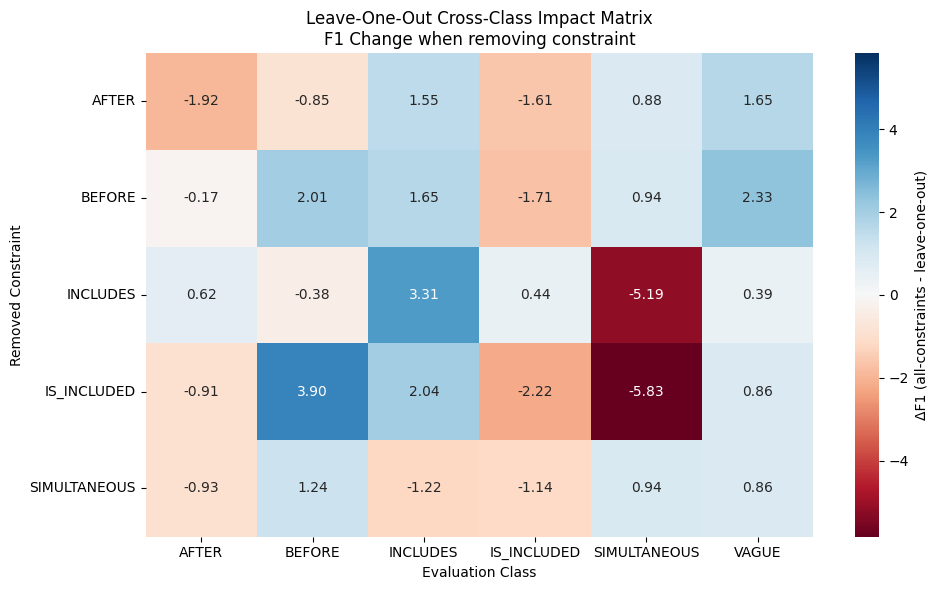

In [32]:
diff_data = leave_out.copy()

for model in models:
    diff_data[f"without_{model}"] = all_constraints["all_constraints"] - leave_out[f"without_{model}"]

heatmap_data = diff_data.drop(columns=["class"]).T
heatmap_data.columns = labels

heatmap_data.index = [idx.replace("without_", "").upper() for idx in heatmap_data.index]
heatmap_data.columns = [col.upper() for col in heatmap_data.columns]

heatmap_data = heatmap_data * 100

diagonal_leave_out = np.diag(heatmap_data.values)



max_abs = np.abs(heatmap_data.values).max()

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    vmin=-max_abs,
    vmax=max_abs,
    cbar_kws={"label": "ΔF1 (all-constraints - leave-one-out)"},
)
plt.xlabel("Evaluation Class")
plt.ylabel("Removed Constraint")
plt.title("Leave-One-Out Cross-Class Impact Matrix\nF1 Change when removing constraint")
plt.tight_layout()
plt.show()

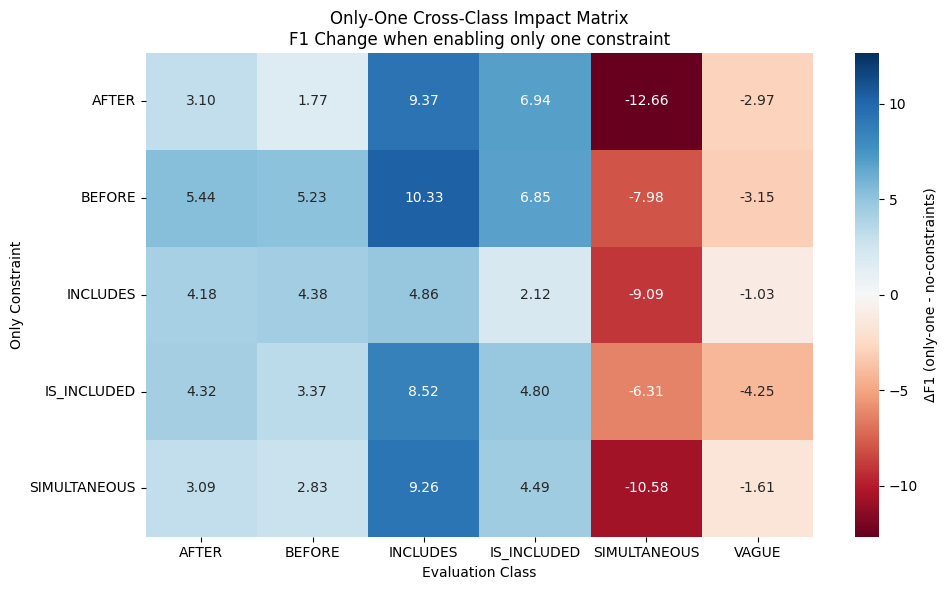

In [ ]:
diff_data = only_one.copy()

for model in models:
    diff_data[f"only_{model}"] = only_one[f"only_{model}"] - augmented["augmented"]

heatmap_data = diff_data.drop(columns=["class"]).T
heatmap_data.columns = labels

heatmap_data.index = [idx.replace("only_", "").upper() for idx in heatmap_data.index]
heatmap_data.columns = [col.upper() for col in heatmap_data.columns]

heatmap_data = heatmap_data * 100

diagonal_only_one = np.diag(heatmap_data.values)



max_abs = np.abs(heatmap_data.values).max()


plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    vmin=-max_abs,
    vmax=max_abs,


    
    cbar_kws={"label": "ΔF1 (only-one - no-constraints)"},
)
plt.xlabel("Evaluation Class")
plt.ylabel("Only Constraint")
plt.title("Only-One Cross-Class Impact Matrix\nF1 Change when enabling only one constraint")
plt.tight_layout()
plt.show()

In [35]:
diagonal_difference = diagonal_leave_out - diagonal_only_one
diagonal_difference

array([-5.01753081, -3.22092373, -1.55141178, -7.026711  , 11.51857197])

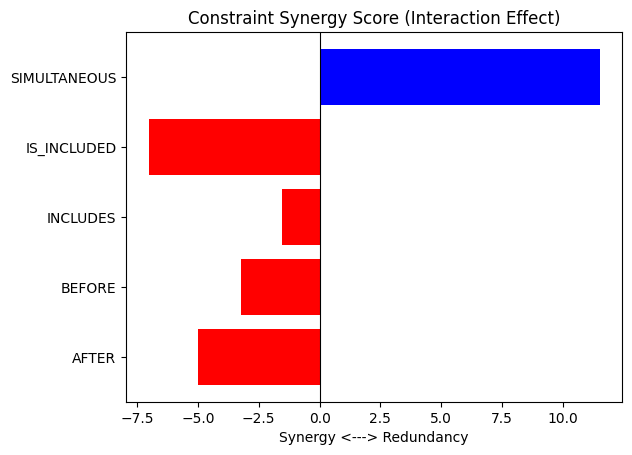

In [36]:
relations = ['AFTER', 'BEFORE', 'INCLUDES', 'IS_INCLUDED', 'SIMULTANEOUS']

scores = [-5.01, -3.22, -1.55, -7.02, 11.51] 

colors = ['red' if x < 0 else 'blue' for x in scores]
plt.barh(relations, scores, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Constraint Synergy Score (Interaction Effect)')
plt.xlabel('Synergy <---> Redundancy')
plt.show()